# Rotating truncated homogeneous sphere collapse


In [1]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import math
from mpl_toolkits.mplot3d import Axes3D
from sklearn.neighbors import KernelDensity

### Generating the truncated sphere

In [2]:
a=1 #radius of the sphere
N=5000 #number of particles

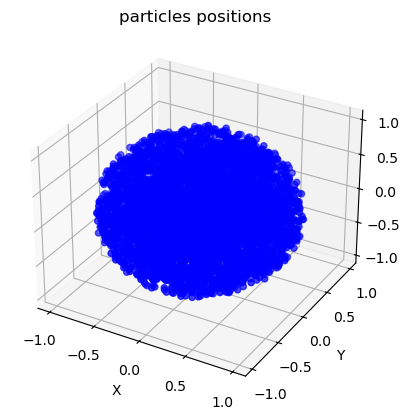

(0.0, 0.6)

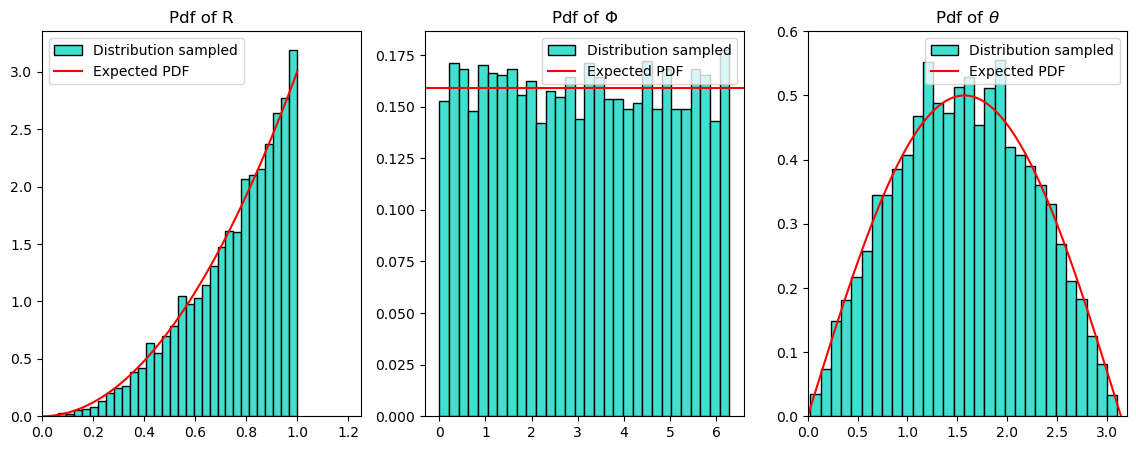

In [11]:
#sample of the radii
P=np.random.uniform(0, 1, N)
r_0=[]
r_0=a*P**(1/3)

#sample of phi
phi=np.random.uniform(0, 2*np.pi, N)

#sample of theta
P1=np.random.uniform(0, 1, N)
theta=[]
for i in range(0, N):
    theta=np.append(theta, math.acos(1-2*P1[i]))

x_0=[]
y_0=[]
z_0=[]

#conevrting the positions from spherical coords to cartesian ones (because the code works with cartesian coords)
for i in range(0, N):
    x_0=np.append(x_0, r_0[i]*math.sin(theta[i])*math.cos(phi[i]))
    y_0=np.append(y_0, r_0[i]*math.sin(theta[i])*math.sin(phi[i]))
    z_0=np.append(z_0, r_0[i]*math.cos(theta[i]))

#Verify that the points form a sphere (of radius=a)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_0, y_0, z_0, c='b', marker='o')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title('particles positions')
plt.show()

x_grid_r = np.linspace(0, a, 100)
x_grid_phi = np.linspace(0, 10, 100)
x_grid_th = np.linspace(0, 3.2, 100)

#Showing the distributions
fig2, ax2 = plt.subplots(1, 3, figsize=(14,5))
ax2[0].hist(r_0, bins=30, density = True, edgecolor='black', color='turquoise', label='Distribution sampled')
ax2[0].set_title('Pdf of R')
ax2[0].set_xlim(0, a+0.25)
ax2[0].plot(x_grid_r, (3*x_grid_r**2/a**3), color = 'red', label='Expected PDF')
ax2[0].legend()

ax2[1].hist(phi, bins=30, density = True, edgecolor='black', color='turquoise', label='Distribution sampled')
ax2[1].set_title(r'Pdf of $\Phi$')
ax2[1].axhline(1/(2*np.pi), color = 'red', label='Expected PDF')
ax2[1].legend()

ax2[2].hist(theta, bins=30, density = True, edgecolor='black', color='turquoise', label='Distribution sampled')
ax2[2].set_title(r'Pdf of $\theta$')
ax2[2].plot(x_grid_th, np.sin(x_grid_th)/2, color = 'red', label='Expected PDF')
ax2[2].legend()
ax2[2].set_xlim(0, 3.2)
ax2[2].set_ylim(0, 0.6)

### Set the initial velocities
We want the sphere to rotate as a rigid body around the z axis, so the velocities should be: \
$v_x = -\omega * y $ \
$v_y = \omega * x$\
$v_z = 0$\
where $\omega$ is the angular velocity of the body. 

In [12]:
omega = 0.5 

vx_0 = -omega * y_0
vy_0 = omega * x_0
vz_0 = np.zeros(N)        

### Save them into an input file

In [13]:
starting_time=0
num_dimensions=3
m=np.ones(N)/N #mass of each particle in internal units 

#file for the C code
with open("Rotating_sphere5000.in", "w") as f:     
    print(N, num_dimensions, starting_time, sep="\n", file=f)
    np.savetxt(f, np.column_stack([m]), delimiter=" ")  
    np.savetxt(f, np.column_stack([x_0, y_0, z_0]), delimiter=" ")
    np.savetxt(f, np.column_stack([vx_0, vy_0, vz_0]), delimiter=" ")

### Compute the expected quantity

In [3]:
#Conversion in IU
G_p = 6.67259e-8 #G in cgs
M_sun = 1.9891e33 #solar mass in g
R_sun = 6.9598e10 #solar radius in cm 
year = 3.14159e7
ly = 9.463e17 #light year in cm
parsec = 3.086e18 #parsec in cm
AU = 1.496e13 #astronomical unit in cm

def v_IU(v_p, M_p=M_sun, r_p=AU):    #because 1 M_i = 1 M_sun and 1 r_i = 1 AU
    return np.sqrt(r_p / (G_p * M_p)) * v_p

def t_IU(t_p, M_p=M_sun, r_p=AU):
    return ((t_p / r_p)*(np.sqrt((G_p * M_p)/r_p)))

t_iu_yr = 6.251839 #1 yr is 6.251839 IU
v_iu_cgs = 3.357e-7 #1 cm/s is 3.357e-7 IU

M = 1 #Total mass in IU that corresponds to 5000 solar masses
M_i = M / N #Single particle mass, that is 1 IU

In [4]:
#Compute the dynamical time and the collapse time in years

volume = 4/3 * np.pi * a**3

density_0 = M / volume #Initial density

t_dyn_IU = np.sqrt(3 * np.pi / (16 * density_0))  #G_i=1!

t_coll_IU = t_dyn_IU / np.sqrt(2) 

#Conversion in physical units
t_dyn = t_dyn_IU / t_iu_yr

t_coll = t_coll_IU / t_iu_yr

#eps = 1e-4 * (volume / N)**(-1/3)
#print("Epsilon = " + str(eps))

print("Dynamical time:" + f"{t_dyn: .4f}" + " yr")
print("Dynamical time (IU):"  + f"{t_dyn_IU: .4f}") 
print("Collapse time:" + f"{t_coll: .5f}" + " yr")
print("Collapse time (IU): " + f"{t_coll_IU: .5f}")
print("Initial density (IU):" + f"{density_0: .3e}")

Dynamical time: 0.2513 yr
Dynamical time (IU): 1.5708
Collapse time: 0.17766 yr
Collapse time (IU):  1.11072
Initial density (IU): 2.387e-01


Comand:./treecode in=Rotating_sphere5000.in out=Rotating_sphere5000.out dtime=0.05 eps=0.05 theta=0.1 tstop=3 dtout=0.05 > energy_rotating_sphere5000.log

### Get the data

In [5]:
#per il momento sono tutti in IU
def GetData(filename, N):
    file_output = open(filename, "r")
    output = file_output.read().splitlines()
    data = []
    time = []
    
    for i in range(3, len(output), 3 * N + 3):
        for j in range(N, 3 * N):
            data.append(output[i + j].split())
        
        time.append(float(output[i - 1]))
        
    #Convert the time in years
    #time = np.array(time) / t_iu_yr
    
    file_output.close()
    
    return np.array(data), np.array(time)

#Get the evolution in time from the data in the CM frame

def GetCoords(data, t, N):
    
    #Get the coordinates
    
    x_ext, y_ext, z_ext = [], [], []
    
    for i in range(0, len(t)):
        x_ext.append([])
        y_ext.append([])
        z_ext.append([])
        
    #Every row contains the coordinate of the i-th particle, every column contains its evolution in time
    
    row = 0
    
    for i in range(0, len(data), 2 * N):    
        for j in range(0, N):
            x_ext[row].append(float(data[i + j][0]))
            y_ext[row].append(float(data[i + j][1]))
            z_ext[row].append(float(data[i + j][2]))
        
        row += 1
    
    #Convert the coordinates to the CM frame
        
    x_ext = np.array(x_ext)
    y_ext = np.array(y_ext)
    z_ext = np.array(z_ext)
    
    x_CM = M_i * np.sum(x_ext, axis=1) / M   #le masse sono tutte uguali
    y_CM = M_i * np.sum(y_ext, axis=1) / M
    z_CM = M_i * np.sum(z_ext, axis=1) / M
    
    x = x_ext - x_CM[0]
    y = y_ext - y_CM[0]
    z = z_ext - z_CM[0]

    return x, y, z


#Get the velocities in time in the CM frame

def GetVelocities(data, t, N):
    
    #Get the coordinates
    
    vx_ext, vy_ext, vz_ext = [], [], []
    
    for i in range(0, len(t)):
        vx_ext.append([])
        vy_ext.append([])
        vz_ext.append([])
        
    #Every row contains the coordinate of the i-th particle, every column contains its evolution in time
    
    row = 0
    
    for i in range(N, len(data), 2 * N):    
        for j in range(0, N):
            vx_ext[row].append(float(data[i + j][0]))
            vy_ext[row].append(float(data[i + j][1]))
            vz_ext[row].append(float(data[i + j][2]))
        
        row += 1
    
    #Convert the coordinates to the CM frame
        
    vx_ext = np.array(vx_ext)
    vy_ext = np.array(vy_ext)
    vz_ext = np.array(vz_ext)
    
    vx_CM = M_i * np.sum(vx_ext, axis=1) / M
    vy_CM = M_i * np.sum(vy_ext, axis=1) / M
    vz_CM = M_i * np.sum(vz_ext, axis=1) / M
    
    K_CM = M * (vx_CM**2 + vy_CM**2 + vz_CM**2) / 2   #energia cinetica del centro di massa 
    
    vx = vx_ext - vx_CM[0]
    vy = vy_ext - vy_CM[0]
    vz = vz_ext - vz_CM[0]

    v_CM = np.sqrt(vx_CM**2 + vy_CM**2 + vz_CM**2)

    return vx, vy, vz, K_CM, v_CM

In [6]:
data, t = GetData("Rotating_sphere5000.out", N)
x, y, z = GetCoords(data, t, N)
vx, vy, vz, K_CM, v_CM = GetVelocities(data, t, N)

In [17]:
len(x)

61

### Check how the particles move

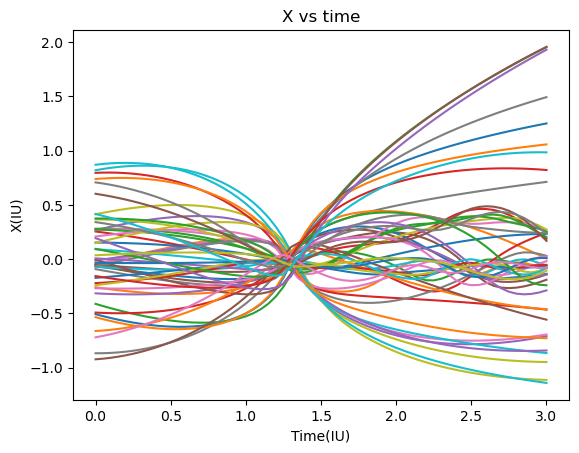

In [7]:
plt.title("X vs time")
plt.xlabel("Time(IU)")
plt.ylabel("X(IU)")
x_s = np.zeros(len(t))
for j in range(0, N, 100):
    for i in range(len(t)):
        x_s[i] = x[i][j]
    plt.plot(t, x_s)

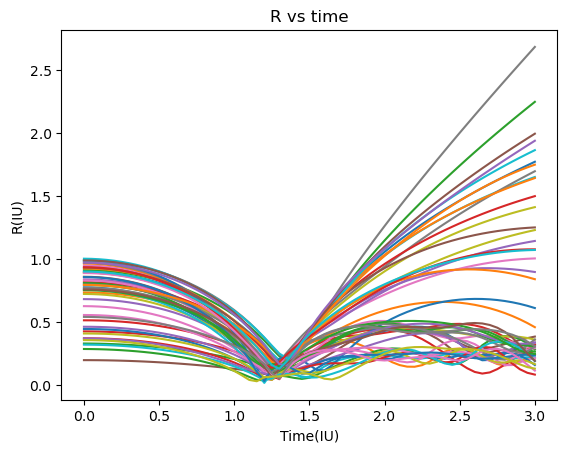

In [8]:
r = np.sqrt(x**2 + y**2 + z**2)
plt.title("R vs time")
plt.xlabel("Time(IU)")
plt.ylabel("R(IU)")

r_s = np.zeros(len(t))

for j in range(0, N, 100):
    for i in range(len(t)):
        r_s[i] = r[i][j]
    plt.plot(t, r_s)

### Get the energies from log file and plot them

In [9]:
def GetEnergy(filename, N, K_CM):
    file_output = open(filename, "r")
    output = np.array(file_output.read().splitlines())
    
    idx = np.where(output == output[9])[0] #Find the row with T and U
    
    K = []
    U = []
    
    for i in idx:
        K.append(float(output[i + 1].split()[1]))
        U.append(-float(output[i + 1].split()[2]))
        
    K = (np.array(K) - K_CM) #* M_sun / v_iu_cgs**2
    U = np.array(U) #* G_p * M_sun**2 / AU

    E = K + U
    
    file_output.close()
    
    return E, K, U 
    
E, K, U = GetEnergy("energy_rotating_sphere5000.log", N, K_CM)

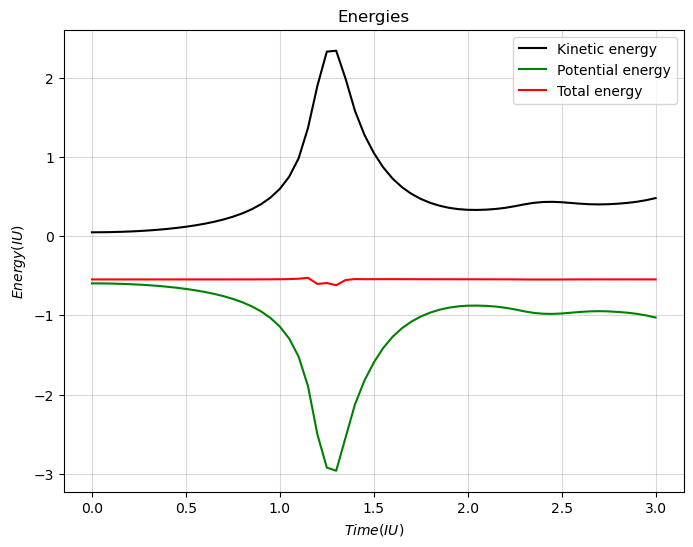

In [10]:
fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('$Time (IU)$')
ax2.set_ylabel('$Energy (IU)$')
ax2.plot(t, K, label = 'Kinetic energy', c= 'black')
ax2.plot(t, U, label = 'Potential energy', c='green')
ax2.plot(t, E, label = 'Total energy', c='red')
ax2.set_title('Energies')
ax2.legend()

In [11]:
#Evaluate the collapse time from the potential energy minimum 
min_index = np.argmin(U)
t_coll_simulation = t[min_index]
print("Collapse time from simulation:", t_coll_simulation)

Collapse time from simulation: 1.2999998


### Movie of the simulation

In [7]:
import os
import imageio.v2 as imageio

# Toggle on/off the movie maker
make_movie = True

if make_movie:
    # FOLDERS MANAGING
    movie_dir_path = "movie_rotating"
    frames_dir_path = os.path.join(movie_dir_path, "frames")
    movie_frame_name_prefix = "snapshot_img_"

    # Create folders to store the movie and its frames
    if not os.path.isdir(movie_dir_path):
        os.makedirs(frames_dir_path)
    
    # Empty the 'frames' folder
    for file_name in os.listdir(frames_dir_path):
        file_path = os.path.join(frames_dir_path, file_name)
        os.remove(file_path)
    
    # Empty the 'movie' folder
    for file_name in os.listdir(movie_dir_path):
        file_path = os.path.join(movie_dir_path, file_name)
        if os.path.isfile(file_path):
            os.remove(file_path)

    # GENERATING FRAMES
    N_frames = len(t)  # Assumiamo che "t" sia la lista dei tempi

    delete_frames = True  # Se vuoi i frames metti False

    fig = plt.figure(figsize=(16, 9))
    ax = fig.add_subplot(projection='3d')
    ax.set_box_aspect(None, zoom=0.9)  # To prevent z-axis label from being cut off

    # For every snapshot (or for some of them depending on the step of the range() call)
    # plot the position of every particle in 3D space
    for i in range(0, 200, 5):
        for j in range(N):
            ax.scatter(x[i][j], y[i][j], z[i][j], color="blue")

        if i == 0:
            x_lim = ax.get_xlim()
            y_lim = ax.get_ylim()
            z_lim = ax.get_zlim()
        
        ax.set_aspect('equal', 'datalim')
        ax.set_xlim(x_lim)
        ax.set_ylim(y_lim)
        ax.set_zlim(z_lim)

        ax.set_xlabel("$x$")
        ax.set_ylabel("$y$")
        ax.set_zlabel("$z$")

        # Save the current figure with a proper name
        frame_name = movie_frame_name_prefix + str(i).zfill(5) + ".png"
        frame_path = os.path.join(frames_dir_path, frame_name)
        fig.savefig(frame_path)

        # Clear the axes for the next plot
        ax.clear()

    plt.close()

    # ASSEMBLING FRAMES
    movie_img_files = os.listdir(frames_dir_path)
    movie_img_files = sorted(movie_img_files)

    movie_path = os.path.join(movie_dir_path, "movie.mp4")

    # Use the imageio writer to build the movie by appending to it every frame
    # Default fps is 10
    with imageio.get_writer(movie_path, mode='I', fps=10) as writer:
        for filename in movie_img_files:
            image = imageio.imread(os.path.join(frames_dir_path, filename))  # Get the frame
            writer.append_data(image)  # Append the frame

    # Delete individual frames if requested
    if delete_frames:
        for file_name in os.listdir(frames_dir_path):
            file_path = os.path.join(frames_dir_path, file_name)
            os.remove(file_path)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1600, 900) to (1600, 912) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


## Movie with the projection

In [55]:
import os
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# Toggle on/off the movie maker
make_movie = True
if make_movie:
    # FOLDERS MANAGING
    movie_dir_path = "movie_projections5000"
    frames_dir_path = os.path.join(movie_dir_path, "frames")
    movie_frame_name_prefix = "projection_img_"
    
    # Create folders to store the movie and its frames
    if not os.path.isdir(movie_dir_path):
        os.makedirs(movie_dir_path)
    if not os.path.isdir(frames_dir_path):
        os.makedirs(frames_dir_path)
    
    # Empty the 'frames' folder
    for file_name in os.listdir(frames_dir_path):
        file_path = os.path.join(frames_dir_path, file_name)
        os.remove(file_path)
    
    # Empty the 'movie' folder
    for file_name in os.listdir(movie_dir_path):
        file_path = os.path.join(movie_dir_path, file_name)
        if os.path.isfile(file_path):
            os.remove(file_path)
    
    # GENERATING FRAMES
    N_frames = len(t)  # Assumiamo che "t" sia la lista dei tempi
    delete_frames = True  # Se vuoi i frames metti False
    
    # Determine the initial limits for consistent scaling
    all_x = np.array(x[0])
    all_y = np.array(y[0])
    all_z = np.array(z[0])
    
    # Calculate global limits to keep the scale consistent
    x_min, x_max = np.min(all_x), np.max(all_x)
    y_min, y_max = np.min(all_y), np.max(all_y)
    z_min, z_max = np.min(all_z), np.max(all_z)
    
    # Ensure the limits are square for each projection
    max_range_xy = max(x_max - x_min, y_max - y_min)
    max_range_zy = max(z_max - z_min, y_max - y_min)
    max_range_zx = max(z_max - z_min, x_max - x_min)
    
    # Set limits for each projection
    x_center = (x_min + x_max) / 2
    y_center = (y_min + y_max) / 2
    z_center = (z_min + z_max) / 2
    
    x_lim = [x_center - max_range_xy/2 * 1.1, x_center + max_range_xy/2 * 1.1]
    y_lim = [y_center - max_range_xy/2 * 1.1, y_center + max_range_xy/2 * 1.1]
    z_lim = [z_center - max_range_zy/2 * 1.1, z_center + max_range_zy/2 * 1.1]
    
    # For every snapshot (or for some of them depending on the step of the range() call)
    # plot the projections of every particle on the three planes
    for i in range(0, N_frames):
        # Create a figure with a 2x2 grid
        fig = plt.figure(figsize=(16, 12))
        gs = GridSpec(2, 2, figure=fig)
        
        # 3D plot in the top-left
        ax_3d = fig.add_subplot(gs[0, 0], projection='3d')
        ax_3d.scatter(x[i], y[i], z[i], color="blue", s=10)
        ax_3d.set_xlim(x_lim)
        ax_3d.set_ylim(y_lim)
        ax_3d.set_zlim(z_lim)
        ax_3d.set_xlabel("$x$")
        ax_3d.set_ylabel("$y$")
        ax_3d.set_zlabel("$z$")
        ax_3d.set_title("3D View", fontsize=14)
        
        # XY projection (top-right)
        ax_xy = fig.add_subplot(gs[0, 1])
        ax_xy.scatter(x[i], y[i], color="blue", s=10)
        ax_xy.set_xlim(x_lim)
        ax_xy.set_ylim(y_lim)
        ax_xy.set_aspect('equal')
        ax_xy.set_xlabel("$x$")
        ax_xy.set_ylabel("$y$")
        ax_xy.set_title("XY Projection", fontsize=14)
        ax_xy.grid(True, alpha=0.3)
        
        # ZY projection (bottom-left)
        ax_zy = fig.add_subplot(gs[1, 0])
        ax_zy.scatter(y[i], z[i], color="blue", s=10)
        ax_zy.set_xlim(y_lim)
        ax_zy.set_ylim(z_lim)
        ax_zy.set_aspect('equal')
        ax_zy.set_xlabel("$z$")
        ax_zy.set_ylabel("$y$")
        ax_zy.set_title("YZ Projection", fontsize=14)
        ax_zy.grid(True, alpha=0.3)
        
        # ZX projection (bottom-right)
        ax_zx = fig.add_subplot(gs[1, 1])
        ax_zx.scatter(x[i], z[i], color="blue", s=10)
        ax_zx.set_xlim(x_lim)
        ax_zx.set_ylim(z_lim)
        ax_zx.set_aspect('equal')
        ax_zx.set_xlabel("$z$")
        ax_zx.set_ylabel("$x$")
        ax_zx.set_title("XZ Projection", fontsize=14)
        ax_zx.grid(True, alpha=0.3)
        
        # Add time information
        time_text = f"Time: {t[i]:.2f}"
        fig.suptitle(time_text, fontsize=16)
        
        plt.tight_layout()
        
        # Save the current figure with a proper name
        frame_name = movie_frame_name_prefix + str(i).zfill(5) + ".png"
        frame_path = os.path.join(frames_dir_path, frame_name)
        fig.savefig(frame_path, dpi=100)
        
        # Close the figure to free memory
        plt.close(fig)
    
    # ASSEMBLING FRAMES
    movie_img_files = os.listdir(frames_dir_path)
    movie_img_files = sorted(movie_img_files)
    movie_path = os.path.join(movie_dir_path, "projections_movie.mp4")
    
    # Use the imageio writer to build the movie by appending to it every frame
    # Default fps is 10
    with imageio.get_writer(movie_path, mode='I', fps=10) as writer:
        for filename in movie_img_files:
            image = imageio.imread(os.path.join(frames_dir_path, filename))  # Get the frame
            writer.append_data(image)  # Append the frame
    
    # Delete individual frames if requested
    if delete_frames:
        for file_name in os.listdir(frames_dir_path):
            file_path = os.path.join(frames_dir_path, file_name)
            os.remove(file_path)
    
    print(f"Movie created at: {movie_path}")
else:
    print("Movie creation is disabled. Set make_movie = True to enable it.")

Movie created at: movie_projections5000\projections_movie.mp4


### Evaluating other quantities

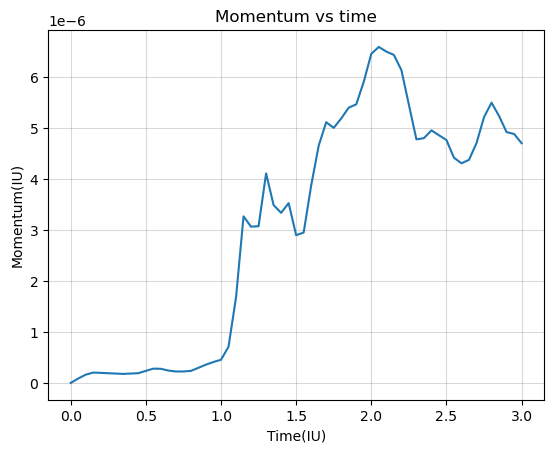

In [25]:
#ATTENZIONE è VETTORIALE
P_i_x = M_i* vx
P_i_y = M_i* vy
P_i_z = M_i* vz
P_tot_x = np.zeros(len(P_i_x))
P_tot_y = np.zeros(len(P_i_x))
P_tot_z = np.zeros(len(P_i_x))

P_tot_i = np.zeros(len(P_i_x))
for i in range(len(P_i_x)):
    P_tot_x[i] = np.sum(P_i_x[i])
    P_tot_y[i] = np.sum(P_i_y[i])
    P_tot_z[i] = np.sum(P_i_z[i])
    P_tot_i[i] = np.sqrt(P_tot_x[i]**2 + P_tot_y[i]**2 + P_tot_z[i]**2)  

plt.plot(t, P_tot_i)
plt.title("Momentum vs time")
plt.xlabel("Time(IU)")
plt.ylabel("Momentum(IU)")
plt.grid(alpha=0.3, c = 'grey')

In [27]:
#Evaluating the total angular momentum of the system at each frame 
positions = np.stack((x, y, z), axis=-1)
velocities = np.stack((vx, vy, vz), axis=-1)
L = np.zeros((len(x), 3)) #(frame, number of coords)
for i in range(len(x)):  #For each frame
    for j in range(N):  # For each particle
        L_i = np.cross(positions[i, j], M_i * velocities[i, j])  # Evaluation of angular mom for each particle 
        L[i] += L_i  # Total angular mom at each frame

L_tot = np.zeros(len(x)) #Total angular mom at each frame not in components
for i in range(len(L)):
    L_tot[i] = np.sqrt(L[i][0]**2 + L[i][1]**2 + L[i][2]**2)
print(L_tot) 

[0.19815725 0.19815723 0.19815728 0.19815734 0.19815731 0.19815729
 0.19815731 0.19815733 0.19815733 0.19815732 0.19815734 0.19815742
 0.19815747 0.19815749 0.19815748 0.19815752 0.1981576  0.19815772
 0.19815788 0.198158   0.198158   0.19815795 0.19815784 0.19815751
 0.19815735 0.19815734 0.19815737 0.19815745 0.19815724 0.19815695
 0.19815671 0.19815646 0.19815649 0.19815665 0.19815679 0.19815701
 0.19815718 0.19815743 0.19815779 0.1981581  0.19815827 0.19815832
 0.19815839 0.19815846 0.19815857 0.19815874 0.19815895 0.19815906
 0.19815907 0.19815909 0.19815902 0.19815889 0.19815875 0.19815876
 0.19815889 0.19815888 0.19815881 0.19815881 0.19815883 0.19815878
 0.19815866]


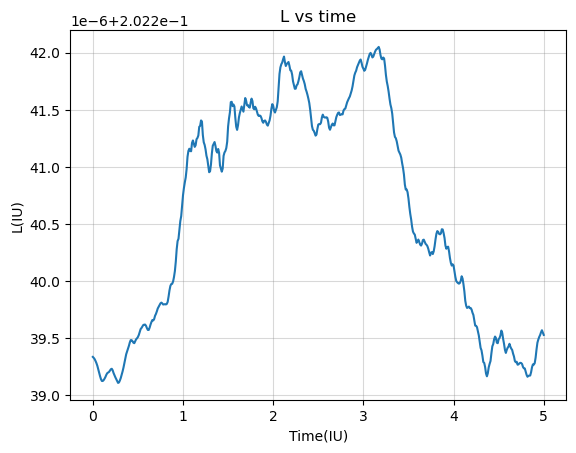

In [50]:
plt.plot(t, L_tot)
plt.title("L vs time")
plt.xlabel("Time(IU)")
plt.ylabel("L(IU)")
plt.grid(alpha=0.3, c = 'grey')

## Ratio between the radius and the z dimension at 1.20 IU

In [14]:
index_disk = np.argmin(np.abs(np.array(t) - 1.2))
index_disk

24

z/r at collapse time is: 0.3048 IU
Maximum radius at collapse time is: 0.4710 IU
Maximum z at collapse time is: 0.1436 IU


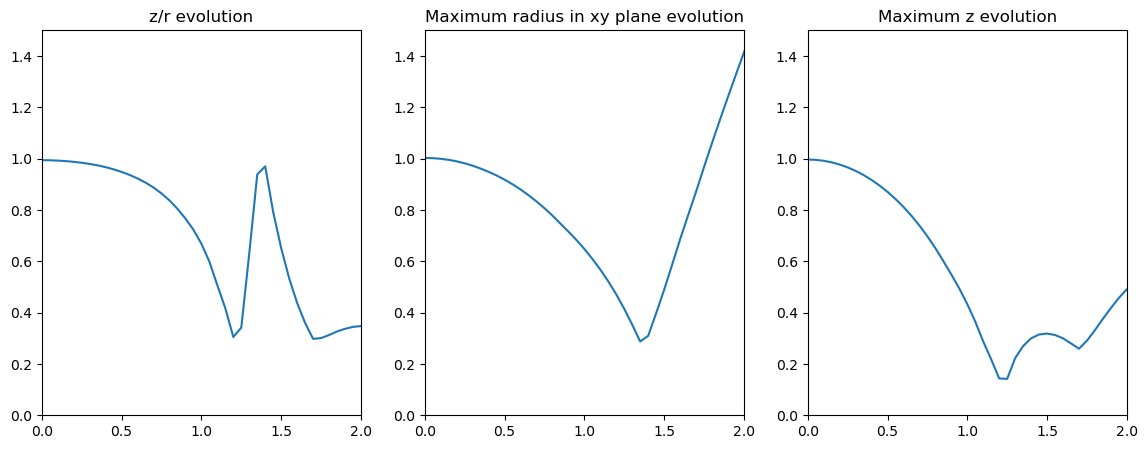

In [20]:
xy = np.sqrt(x**2+y**2)
ratio = np.zeros(len(t))
xy_max = np.zeros(len(t))
z_max = np.zeros(len(t))

for i in range(len(t)):
    z_max[i] = np.max(z[i])
    xy_max[i] = np.max(xy[i])
    ratio[i] = np.max(z[i])/np.max(xy[i])

fig2, ax2 = plt.subplots(1, 3, figsize=(14,5))
ax2[0].plot(t, ratio)
ax2[0].set_title('z/r evolution')
ax2[0].set_xlim(0, 2)
ax2[0].set_ylim(0, 1.5)

ax2[1].plot(t, xy_max)
ax2[1].set_title('Maximum radius in xy plane evolution')
ax2[1].set_xlim(0, 2)
ax2[1].set_ylim(0, 1.5)
#ax2[1].axvline(1.2)

ax2[2].set_title('Maximum z evolution')
ax2[2].plot(t, z_max)
ax2[2].set_xlim(0, 2)
ax2[2].set_ylim(0, 1.5)
print("z/r at collapse time is:"+ f"{ratio[index_disk]: .4f}" + " IU")
print("Maximum radius at collapse time is:"+ f"{xy_max[index_disk]: .4f}" + " IU")
print("Maximum z at collapse time is:"+ f"{z_max[index_disk]: .4f}" + " IU")

## Radial profile

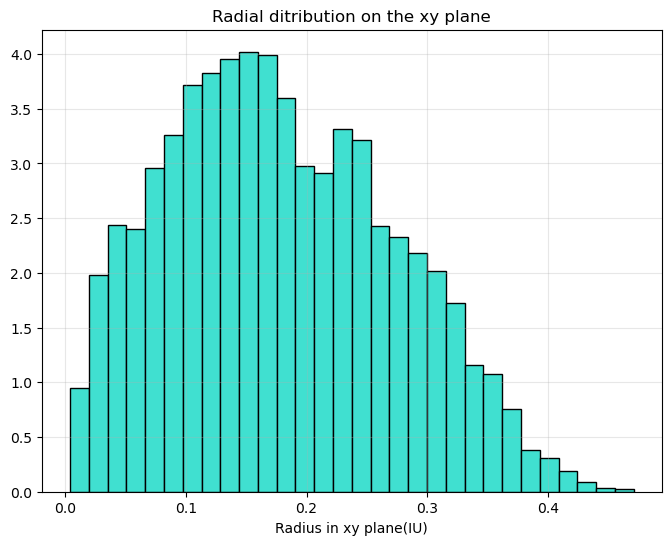

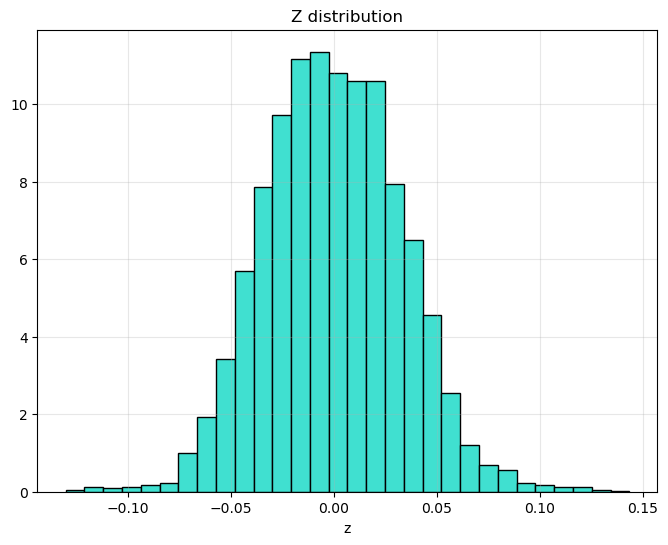

In [18]:
xy_disk = xy[index_disk]
z_disk = z[index_disk]
plt.figure(figsize=(8, 6))
plt.hist(xy_disk, bins=30, density = True, edgecolor='black', color='turquoise')
plt.xlabel('Radius in xy plane(IU)')
plt.title('Radial ditribution on the xy plane')
plt.grid(True, alpha=0.3)

plt.figure(figsize=(8, 6))
plt.hist(z_disk, bins=30, density = True, edgecolor='black', color='turquoise')
plt.xlabel('z')
plt.title('Z distribution')
plt.grid(True, alpha=0.3)

plt.show()

In [32]:
#I defne a function for genereting the distribution of M_irr using a KDE
def KDE(hist, bandwidth, xgrid, kernel):    
   KDE = KernelDensity(bandwidth=bandwidth, kernel= kernel) 
   KDE.fit(hist[:, np.newaxis]) #Sklearn returns log(density)
   return np.exp(KDE.score_samples(xgrid[:, np.newaxis]))

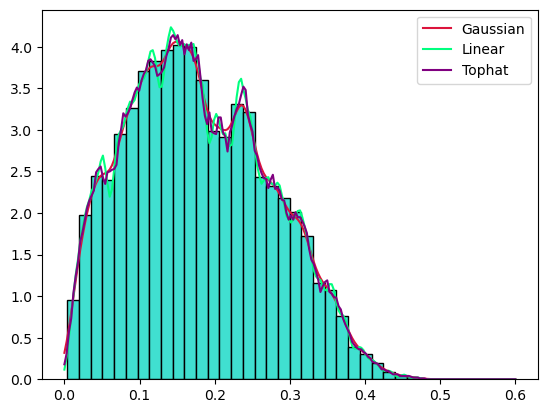

In [33]:
#I plot it using different kernel but with the same bandwidth
xgrid = np.linspace(0, 0.6, 200)
plt.hist(xy_disk, bins=30, density = True, edgecolor='black', color='turquoise')

kde_gauss = KDE(xy_disk, 0.01, xgrid, 'gaussian')
plt.plot(xgrid, kde_gauss, color = 'crimson', label= 'Gaussian')

kde_lin = KDE(xy_disk, 0.01, xgrid, 'linear')
plt.plot(xgrid, kde_lin, color = 'springgreen', label= 'Linear')

kde_top = KDE(xy_disk, 0.01, xgrid, 'tophat')
plt.plot(xgrid, kde_top, color = 'purple', label= 'Tophat')

plt.legend()

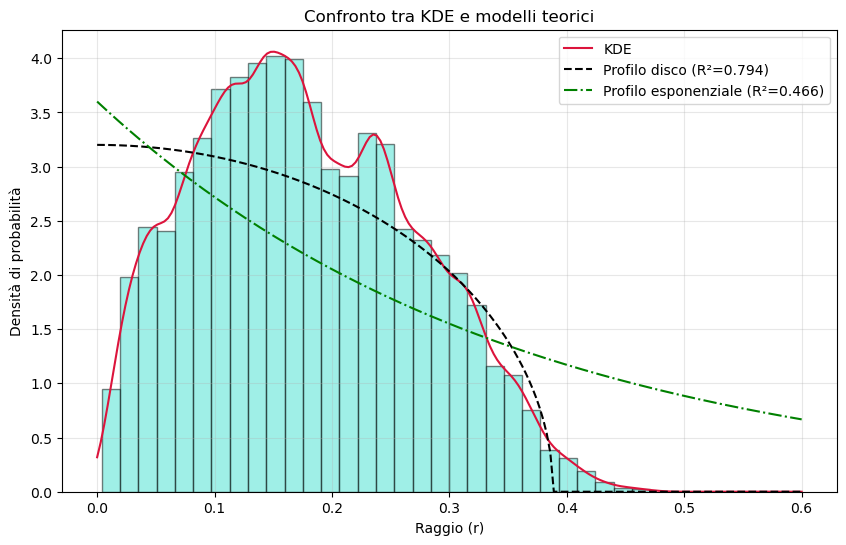

In [45]:
def disco_teorico(r, A, R_max):
    return A * np.sqrt(np.maximum(0, R_max**2 - r**2))
    
def profilo_esponenziale(r, A, r_s):
    return A * np.exp(-r/r_s)
    
def legge_potenza(r, A, alpha):
    return A * r**(-alpha)

from scipy.optimize import curve_fit

# Assumendo che xgrid contenga i valori del raggio e kde_gauss i valori della KDE
params_disco, _ = curve_fit(disco_teorico, xgrid, kde_gauss, p0=[1.0, 0.1])
params_exp, _ = curve_fit(profilo_esponenziale, xgrid, kde_gauss, p0=[1.0, 0.1])
#params_power, _ = curve_fit(legge_potenza, xgrid, kde_gauss, p0=[1.0, 1.5])

def r_squared(y_true, y_pred):
    residuals = y_true - y_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

r2_disco = r_squared(kde_gauss, disco_teorico(xgrid, *params_disco))
r2_exp = r_squared(kde_gauss, profilo_esponenziale(xgrid, *params_exp))
#r2_power = r_squared(kde_gauss, legge_potenza(xgrid, *params_power))

plt.figure(figsize=(10, 6))
plt.hist(xy_disk, bins=30, density=True, edgecolor='black', color='turquoise', alpha=0.5)
plt.plot(xgrid, kde_gauss, color='crimson', label='KDE')
plt.plot(xgrid, disco_teorico(xgrid, *params_disco), 'k--', label=f'Profilo disco (R²={r2_disco:.3f})')
plt.plot(xgrid, profilo_esponenziale(xgrid, *params_exp), 'g-.', label=f'Profilo esponenziale (R²={r2_exp:.3f})')
#plt.plot(xgrid, legge_potenza(xgrid, *params_power), 'b:', label=f'Legge di potenza (R²={r2_power:.3f})')
plt.xlabel('Raggio (r)')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.title('Confronto tra KDE e modelli teorici')
plt.grid(alpha=0.3)
plt.show()

Parametri disco: A=8.2415, R_max=0.3884
Parametri esponenziale: A=3.6008, r_s=0.3561
Parametri legge di potenza: A=1.0565, alpha=0.3169


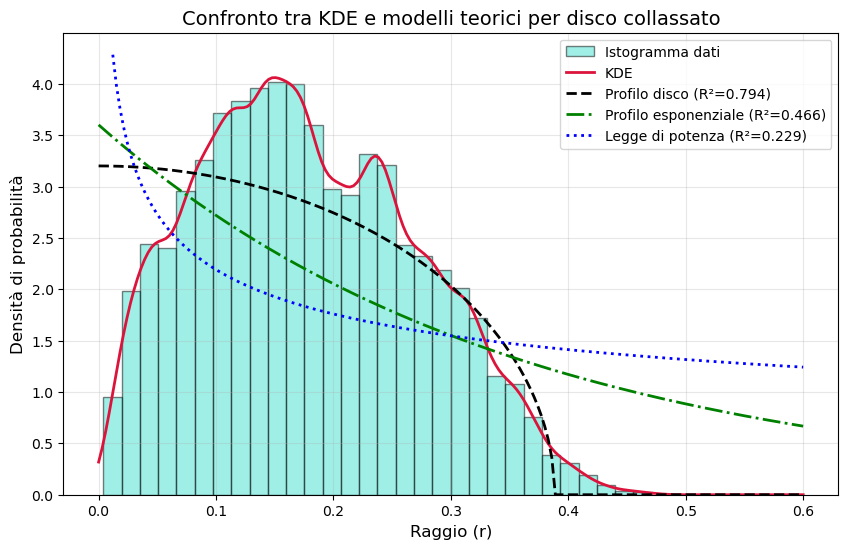

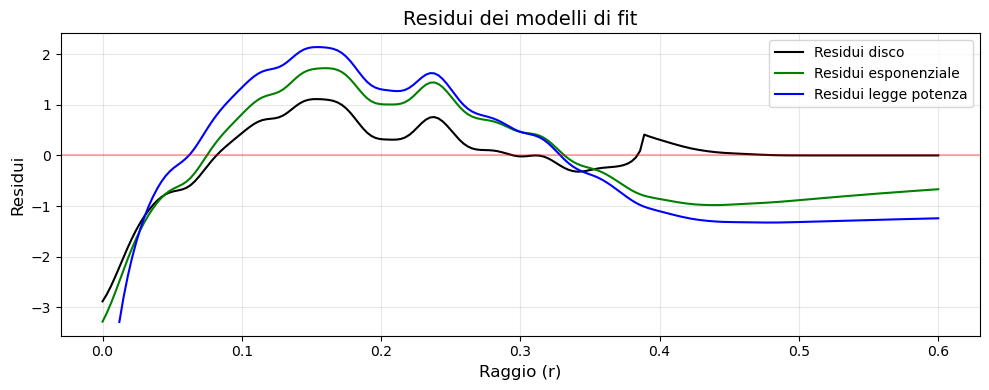


Il modello che meglio descrive i dati è: Profilo disco con R²=0.7939

AIC Profilo disco: -161.58
AIC Profilo esponenziale: 28.89
AIC Legge di potenza: 101.98
Il modello con AIC minore (migliore) è: Profilo disco


In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Definizione delle funzioni di fit modificate
def disco_teorico(r, A, R_max):
    # Assicura che non ci siano radici negative
    return A * np.sqrt(np.maximum(0, R_max**2 - r**2))
    
def profilo_esponenziale(r, A, r_s):
    return A * np.exp(-r/r_s)
    
def legge_potenza(r, A, alpha, r_min=1e-6):
    # Aggiungiamo un raggio minimo per evitare divisione per zero
    return A * (r + r_min)**(-alpha)

# Assumendo che xgrid e kde_gauss siano già definiti
# Filtriamo i valori di r troppo piccoli per il fit della legge di potenza
mask = xgrid > 0.01  # Escludiamo valori troppo vicini a zero

# Eseguiamo i fit
try:
    params_disco, covar_disco = curve_fit(disco_teorico, xgrid, kde_gauss, p0=[1.0, 0.2])
    A_disco, R_max = params_disco
    print(f"Parametri disco: A={A_disco:.4f}, R_max={R_max:.4f}")
except RuntimeError as e:
    print(f"Errore nel fit del profilo disco: {e}")
    params_disco = [0, 0]

try:
    params_exp, covar_exp = curve_fit(profilo_esponenziale, xgrid, kde_gauss, p0=[1.0, 0.1])
    A_exp, r_s = params_exp
    print(f"Parametri esponenziale: A={A_exp:.4f}, r_s={r_s:.4f}")
except RuntimeError as e:
    print(f"Errore nel fit del profilo esponenziale: {e}")
    params_exp = [0, 0]

try:
    # Utilizziamo solo i valori validi per il fit della legge di potenza
    params_power, covar_power = curve_fit(
        legge_potenza, 
        xgrid[mask], 
        kde_gauss[mask], 
        p0=[1.0, 1.5],
        bounds=([0, 0], [np.inf, 10]),  # Limiti più stringenti per stabilità
        maxfev=2000  # Aumentiamo il numero massimo di iterazioni
    )
    A_power, alpha = params_power
    print(f"Parametri legge di potenza: A={A_power:.4f}, alpha={alpha:.4f}")
except RuntimeError as e:
    print(f"Errore nel fit della legge di potenza: {e}")
    params_power = [0, 0]

# Funzione per calcolare R²
def r_squared(y_true, y_pred):
    residuals = y_true - y_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

# Calcoliamo l'R² per ogni modello
y_disco = disco_teorico(xgrid, *params_disco)
r2_disco = r_squared(kde_gauss, y_disco)

y_exp = profilo_esponenziale(xgrid, *params_exp)
r2_exp = r_squared(kde_gauss, y_exp)

# Per la legge di potenza, calcoliamo R² solo sui dati validi
y_power = np.zeros_like(kde_gauss)
y_power[mask] = legge_potenza(xgrid[mask], *params_power)
r2_power = r_squared(kde_gauss[mask], y_power[mask])

# Visualizziamo i risultati
plt.figure(figsize=(10, 6))
plt.hist(xy_disk, bins=30, density=True, edgecolor='black', color='turquoise', alpha=0.5, label='Istogramma dati')
plt.plot(xgrid, kde_gauss, color='crimson', linewidth=2, label='KDE')
plt.plot(xgrid, y_disco, 'k--', linewidth=2, label=f'Profilo disco (R²={r2_disco:.3f})')
plt.plot(xgrid, y_exp, 'g-.', linewidth=2, label=f'Profilo esponenziale (R²={r2_exp:.3f})')
plt.plot(xgrid[mask], y_power[mask], 'b:', linewidth=2, label=f'Legge di potenza (R²={r2_power:.3f})')

plt.xlabel('Raggio (r)', fontsize=12)
plt.ylabel('Densità di probabilità', fontsize=12)
plt.legend(fontsize=10)
plt.title('Confronto tra KDE e modelli teorici per disco collassato', fontsize=14)
plt.grid(alpha=0.3)

# Aggiungiamo un plot dei residui
plt.figure(figsize=(10, 4))
plt.plot(xgrid, kde_gauss - y_disco, 'k-', label='Residui disco')
plt.plot(xgrid, kde_gauss - y_exp, 'g-', label='Residui esponenziale')
plt.plot(xgrid[mask], kde_gauss[mask] - y_power[mask], 'b-', label='Residui legge potenza')
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.xlabel('Raggio (r)', fontsize=12)
plt.ylabel('Residui', fontsize=12)
plt.legend(fontsize=10)
plt.title('Residui dei modelli di fit', fontsize=14)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Determinare quale modello è il migliore
r2_values = [r2_disco, r2_exp, r2_power]
model_names = ['Profilo disco', 'Profilo esponenziale', 'Legge di potenza']
best_model_index = np.argmax(r2_values)
print(f"\nIl modello che meglio descrive i dati è: {model_names[best_model_index]} con R²={r2_values[best_model_index]:.4f}")

# Calcolo dell'Akaike Information Criterion (AIC) per una valutazione più robusta
def aic(n_params, n_samples, rss):
    """Calcola l'AIC: un valore più basso indica un modello migliore"""
    return 2 * n_params + n_samples * np.log(rss / n_samples)

rss_disco = np.sum((kde_gauss - y_disco)**2)
rss_exp = np.sum((kde_gauss - y_exp)**2)
rss_power = np.sum((kde_gauss[mask] - y_power[mask])**2)

aic_disco = aic(2, len(kde_gauss), rss_disco)
aic_exp = aic(2, len(kde_gauss), rss_exp)
aic_power = aic(2, len(kde_gauss[mask]), rss_power)

print(f"\nAIC Profilo disco: {aic_disco:.2f}")
print(f"AIC Profilo esponenziale: {aic_exp:.2f}")
print(f"AIC Legge di potenza: {aic_power:.2f}")
print(f"Il modello con AIC minore (migliore) è: {model_names[np.argmin([aic_disco, aic_exp, aic_power])]}")

Text(0, 0.5, 'Z')

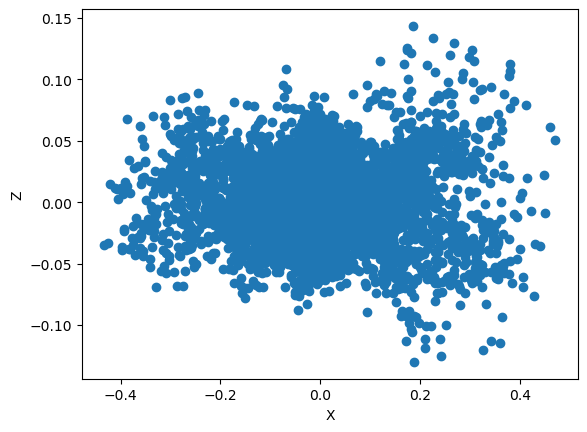

In [44]:
plt.scatter(x[24], z[24])
plt.xlabel('X')
plt.ylabel('Z')

Text(0, 0.5, 'y')

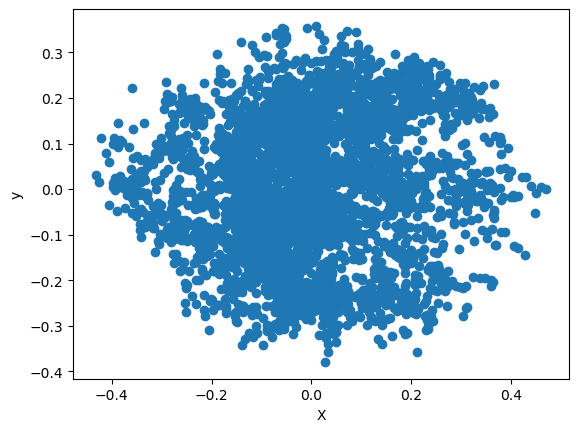

In [35]:
plt.scatter(x[index_disk], y[index_disk])
plt.xlabel('X')
plt.ylabel('y')

## The same but with physical units

In [48]:
t_ph = t / t_iu_yr #year
x_ph = x * AU      #cm
y_ph = y * AU
z_ph = z * AU
vx_ph = vx / v_iu_cgs  #cm/s
vy_ph = vy / v_iu_cgs
vz_ph = vz / v_iu_cgs
M_ph = M*M_sun
M_i_ph = M_i*M_sun

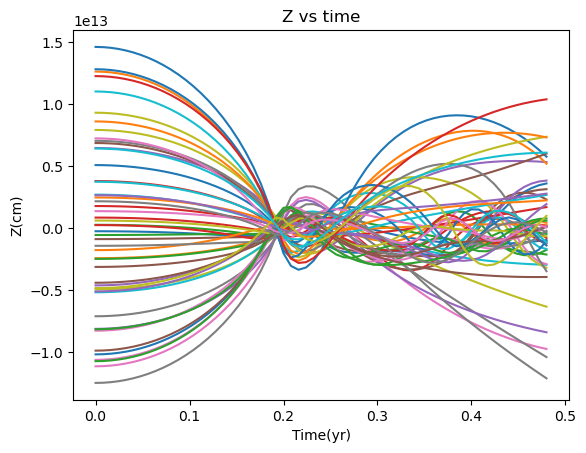

In [49]:
z_1_ph = np.zeros(len(t_ph))
plt.title("Z vs time")
plt.xlabel("Time(yr)")
plt.ylabel("Z(cm)")
for j in range(0, N, 100):
    for i in range(len(t)):
        z_1_ph[i] = z_ph[i][j]
    plt.plot(t_ph, z_1_ph)

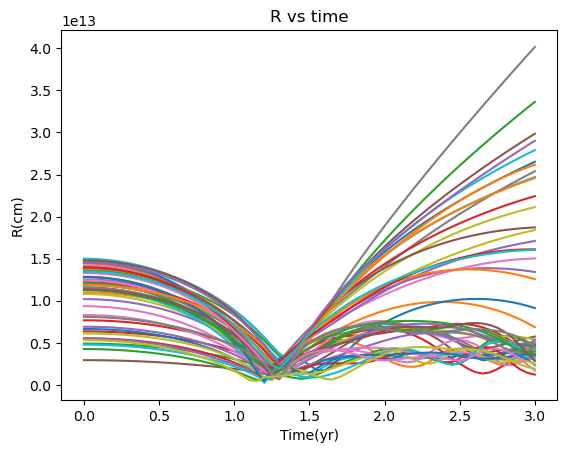

In [50]:
r_ph = np.sqrt(x_ph**2 + y_ph**2 + z_ph**2)
plt.title("R vs time")
plt.xlabel("Time(yr)")
plt.ylabel("R(cm)")

r_s_ph = np.zeros(len(t))

for j in range(0, N, 100):
    for i in range(len(t)):
        r_s_ph[i] = r_ph[i][j]
    plt.plot(t, r_s_ph)

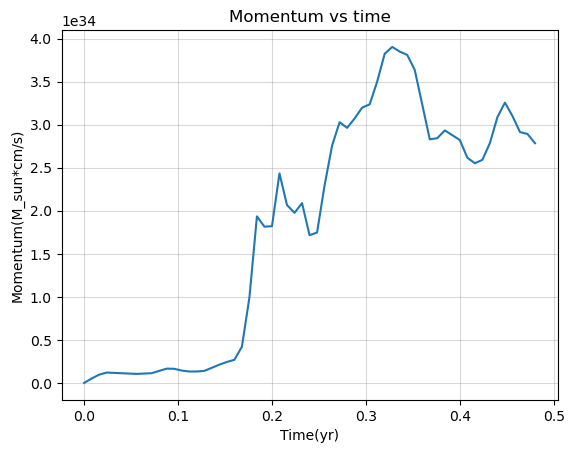

In [51]:
#ATTENZIONE è VETTORIALE
P_i_x_ph = M_i_ph* vx_ph
P_i_y_ph = M_i_ph* vy_ph
P_i_z_ph = M_i_ph* vz_ph
P_tot_x_ph = np.zeros(len(P_i_x_ph))
P_tot_y_ph = np.zeros(len(P_i_x_ph))
P_tot_z_ph = np.zeros(len(P_i_x_ph))

P_tot_i_ph = np.zeros(len(P_i_x_ph))
for i in range(len(P_i_x_ph)):
    P_tot_x_ph[i] = np.sum(P_i_x_ph[i])
    P_tot_y_ph[i] = np.sum(P_i_y_ph[i])
    P_tot_z_ph[i] = np.sum(P_i_z_ph[i])
    P_tot_i_ph[i] = np.sqrt(P_tot_x_ph[i]**2 + P_tot_y_ph[i]**2 + P_tot_z_ph[i]**2)  

plt.plot(t_ph, P_tot_i_ph)
plt.title("Momentum vs time")
plt.xlabel("Time(yr)")
plt.ylabel("Momentum(M_sun*cm/s)")
plt.grid(alpha=0.3, c = 'grey')

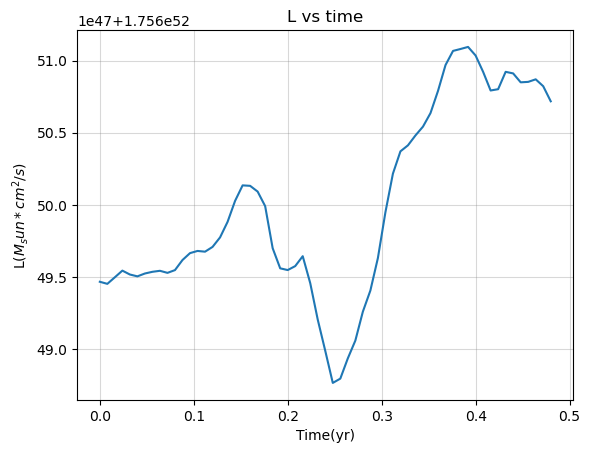

In [52]:
#Evaluating the total angular momentum of the system at each frame 
positions_ph = np.stack((x_ph, y_ph, z_ph), axis=-1)
velocities_ph = np.stack((vx_ph, vy_ph, vz_ph), axis=-1)
L_ph = np.zeros((len(x_ph), 3)) #(frame, number of coords)
for i in range(len(x_ph)):  #For each frame
    for j in range(N):  # For each particle
        L_i_ph = np.cross(positions_ph[i, j], M_i_ph * velocities_ph[i, j])  # Evaluation of angular mom for each particle 
        L_ph[i] += L_i_ph  # Total angular mom at each frame

L_tot_ph = np.zeros(len(x_ph)) #Total angular mom at each frame not in components
for i in range(len(L_ph)):
    L_tot_ph[i] = np.sqrt(L_ph[i][0]**2 + L_ph[i][1]**2 + L_ph[i][2]**2)

plt.plot(t_ph, L_tot_ph)
plt.title("L vs time")
plt.xlabel("Time(yr)")
plt.ylabel(r'L($M_sun*cm^2/s$)')
plt.grid(alpha=0.3, c = 'grey')